[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/healthcareaibook/blob/main/vol%201%20notebooks/chapter_11/notebook_11_3_adversarial_robustness.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# Notebook 11.3: Adversarial Robustness

**Volume 1: Foundations of AI in Healthcare**  
**Chapter 11: Privacy, Security, and Trustworthy AI**

---

## Introduction

Machine learning models, despite their impressive performance, can be surprisingly fragile. **Adversarial examples** are inputs that have been deliberately crafted with imperceptible perturbations to cause models to make mistakes. In healthcare, these vulnerabilities pose serious risks:

### Clinical Motivations

1. **Medical Imaging**: A tiny, imperceptible change to a chest X-ray could cause a model to miss a tumor
2. **Clinical Decision Support**: Manipulated lab values could trick a sepsis prediction model
3. **Drug Discovery**: Adversarial attacks on molecular property predictors could waste research resources
4. **Insurance Fraud**: Attackers might manipulate inputs to obtain favorable risk assessments

### The Adversarial Threat

Consider this striking example:

```
Original Image: "No Pneumonia" (99% confidence)
     ↓ [Add imperceptible noise]
Adversarial Image: "Pneumonia" (95% confidence)
     ↓ [Visually identical to humans]
```

**Key Questions**:
- Why are neural networks vulnerable to adversarial attacks?
- How can we detect adversarial examples?
- How can we make models robust to such attacks?
- What are the trade-offs between robustness and accuracy?

### Learning Objectives

By the end of this notebook, you will:

1. Understand adversarial attack methods: **FGSM**, **PGD**, **C&W**
2. Implement adversarial example generation
3. Evaluate model robustness to adversarial perturbations
4. Learn defense mechanisms: **Adversarial Training**, **Defensive Distillation**
5. Understand the robustness-accuracy trade-off
6. Apply adversarial robustness to medical imaging

---

## Setup

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Try to import TensorFlow (for neural network demos)
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    print(f"TensorFlow version: {tf.__version__}")
    TENSORFLOW_AVAILABLE = True
except ImportError:
    print("TensorFlow not available. Using simplified implementations.")
    TENSORFLOW_AVAILABLE = False

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
if TENSORFLOW_AVAILABLE:
    tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.19.0
Libraries imported successfully!
NumPy version: 2.0.2


---

## Part 1: Understanding Adversarial Examples

### What Are Adversarial Examples?

An **adversarial example** is an input $x'$ created by adding a small perturbation $\delta$ to a legitimate input $x$:

$$
x' = x + \delta
$$

Such that:
1. $\|\delta\|_p \leq \epsilon$ (perturbation is small)
2. $f(x) \neq f(x')$ (model prediction changes)
3. $x$ and $x'$ are indistinguishable to humans

### Why Do They Exist?

Neural networks learn **linear approximations** in high-dimensional space. Small perturbations in many dimensions accumulate:

$$
f(x + \delta) \approx f(x) + \nabla_x f(x)^T \delta
$$

Even if $\|\delta\|$ is tiny, $\nabla_x f(x)^T \delta$ can be large if $\delta$ aligns with the gradient!

### Attack Goals

1. **Untargeted attack**: Make the model predict any wrong class
   $$\text{maximize } \mathcal{L}(x', y_{\text{true}})$$

2. **Targeted attack**: Make the model predict a specific wrong class $y_{\text{target}}$
   $$\text{minimize } \mathcal{L}(x', y_{\text{target}})$$

### Attack Scenarios in Healthcare

- **White-box**: Attacker has full access to model (weights, architecture)
- **Black-box**: Attacker can only query the model
- **Physical**: Attacks work in the real world (e.g., adversarial patches on skin lesions)

---

## Part 2: Fast Gradient Sign Method (FGSM)

### Algorithm

FGSM (Goodfellow et al., 2015) is the simplest and fastest adversarial attack:

$$
x' = x + \epsilon \cdot \text{sign}(\nabla_x \mathcal{L}(x, y_{\text{true}}))
$$

**Intuition**: Move the input in the direction that **maximizes** the loss.

**Parameters**:
- $\epsilon$: Perturbation magnitude (larger = stronger attack, more noticeable)
- $\nabla_x \mathcal{L}$: Gradient of loss w.r.t. input
- $\text{sign}()$: Takes only the direction, not magnitude

**Advantages**:
- Extremely fast (single gradient computation)
- Simple to implement
- Effective on many models

**Limitations**:
- Less powerful than iterative methods
- May not find optimal adversarial examples

In [2]:
# Generate synthetic medical imaging data
def generate_medical_image_data(n_samples=1000, img_size=28):
    """
    Generate synthetic medical image data (simplified).

    In reality, this would be actual chest X-rays, CT scans, etc.
    We use synthetic data to demonstrate adversarial attacks.

    Returns:
        X: Images (n_samples, img_size, img_size)
        y: Binary labels (0 = Normal, 1 = Abnormal)
    """
    np.random.seed(42)

    n_normal = n_samples // 2
    n_abnormal = n_samples - n_normal

    # Normal images: Low intensity with some noise
    normal_images = np.random.randn(n_normal, img_size, img_size) * 0.3 + 0.3

    # Abnormal images: Higher intensity regions (simulating lesions)
    abnormal_images = np.random.randn(n_abnormal, img_size, img_size) * 0.3 + 0.3
    for i in range(n_abnormal):
        # Add bright spots (simulated abnormalities)
        center_x = np.random.randint(img_size // 4, 3 * img_size // 4)
        center_y = np.random.randint(img_size // 4, 3 * img_size // 4)
        size = np.random.randint(3, 8)

        y_grid, x_grid = np.ogrid[:img_size, :img_size]
        mask = (x_grid - center_x)**2 + (y_grid - center_y)**2 <= size**2
        abnormal_images[i][mask] += np.random.uniform(0.5, 1.0)

    # Combine and clip to [0, 1]
    X = np.concatenate([normal_images, abnormal_images])
    X = np.clip(X, 0, 1)

    # Labels
    y = np.concatenate([np.zeros(n_normal), np.ones(n_abnormal)])

    # Shuffle
    indices = np.random.permutation(n_samples)
    X, y = X[indices], y[indices]

    # Add channel dimension for CNN
    X = X[..., np.newaxis]

    return X, y.astype(int)

# Generate data
X, y = generate_medical_image_data(n_samples=1000, img_size=28)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test set: {X_test.shape}, Labels: {y_test.shape}")
print(f"\nClass distribution:")
print(f"  Normal: {(y_test == 0).sum()} ({(y_test == 0).mean():.1%})")
print(f"  Abnormal: {(y_test == 1).sum()} ({(y_test == 1).mean():.1%})")

Training set: (800, 28, 28, 1), Labels: (800,)
Test set: (200, 28, 28, 1), Labels: (200,)

Class distribution:
  Normal: 100 (50.0%)
  Abnormal: 100 (50.0%)


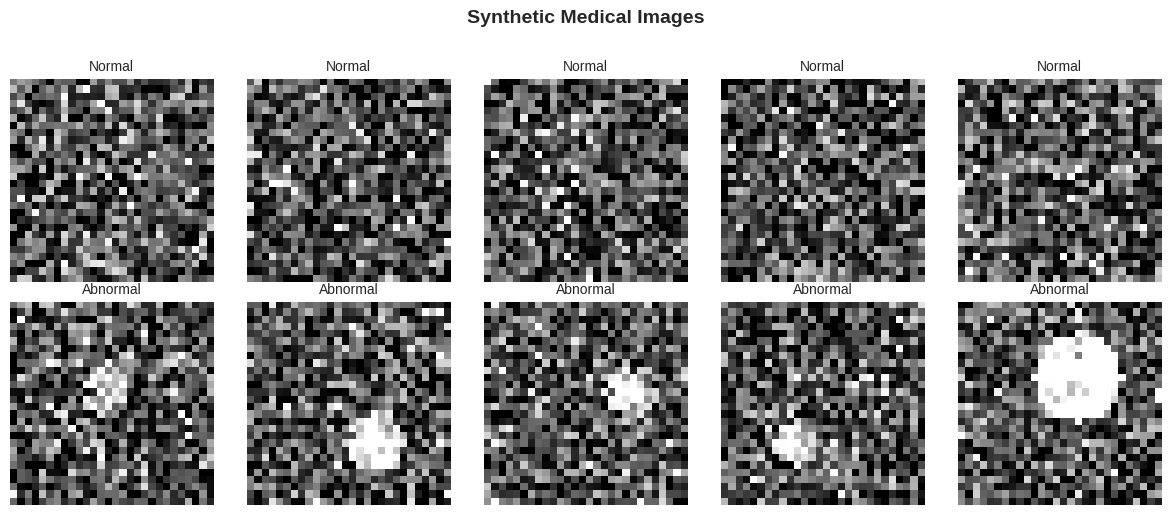

In [6]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    # Normal images
    axes[0, i].imshow(X_test[y_test == 0][i, :, :, 0], cmap='gray')
    axes[0, i].set_title('Normal', fontsize=10)
    axes[0, i].axis('off')

    # Abnormal images
    axes[1, i].imshow(X_test[y_test == 1][i, :, :, 0], cmap='gray')
    axes[1, i].set_title('Abnormal', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Synthetic Medical Images', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Building a Medical Image Classifier

In [7]:
if TENSORFLOW_AVAILABLE:
    # Build a simple CNN for medical image classification
    def build_medical_classifier(input_shape=(28, 28, 1)):
        """Build a CNN for binary medical image classification."""
        model = keras.Sequential([
            layers.Input(shape=input_shape),

            # Convolutional layers
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

            # Fully connected layers
            layers.Flatten(),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(1, activation='sigmoid')  # Binary classification
        ])

        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        return model

    # Build and train model
    model = build_medical_classifier()
    print("Model architecture:")
    model.summary()

    print("\nTraining model...")
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Accuracy (Clean): {test_accuracy:.4f}")
    print(f"Test Loss: {test_loss:.4f}")

else:
    print("TensorFlow not available. Skipping model training.")

Model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,577 (1002.25 KB)

 Trainable params: 256,577 (1002.25 KB)

 Non-trainable params: 0 (0.00 B)


Training model...

Test Accuracy (Clean): 0.9900
Test Loss: 0.0184


### Implementing FGSM Attack

In [8]:
if TENSORFLOW_AVAILABLE:
    def fgsm_attack(model, image, label, epsilon=0.1):
        """
        Fast Gradient Sign Method (FGSM) attack.

        Args:
            model: Target model
            image: Input image (single image)
            label: True label
            epsilon: Perturbation magnitude

        Returns:
            adversarial_image: Perturbed image
            perturbation: Added noise
        """
        # Convert to tensor
        image_tensor = tf.convert_to_tensor(image[np.newaxis, ...])
        label_tensor = tf.convert_to_tensor([label], dtype=tf.float32)

        # Compute gradient of loss w.r.t. input
        with tf.GradientTape() as tape:
            tape.watch(image_tensor)
            prediction = model(image_tensor)
            loss = tf.keras.losses.binary_crossentropy(label_tensor, prediction)

        # Get gradient
        gradient = tape.gradient(loss, image_tensor)

        # Create adversarial example
        # x' = x + epsilon * sign(gradient)
        perturbation = epsilon * tf.sign(gradient)
        adversarial_image = image_tensor + perturbation

        # Clip to valid range [0, 1]
        adversarial_image = tf.clip_by_value(adversarial_image, 0, 1)

        return adversarial_image.numpy()[0], perturbation.numpy()[0]

    # Generate adversarial examples for test set
    print("Generating adversarial examples using FGSM...\n")

    epsilon_values = [0.0, 0.05, 0.1, 0.2, 0.3]
    adversarial_results = {}

    for eps in epsilon_values:
        adversarial_images = []
        for i in range(len(X_test)):
            if eps == 0.0:
                adv_img = X_test[i]
            else:
                adv_img, _ = fgsm_attack(model, X_test[i], y_test[i], epsilon=eps)
            adversarial_images.append(adv_img)

        adversarial_images = np.array(adversarial_images)

        # Evaluate on adversarial examples
        predictions = (model.predict(adversarial_images, verbose=0) > 0.5).astype(int).flatten()
        accuracy = np.mean(predictions == y_test)

        adversarial_results[eps] = {
            'images': adversarial_images,
            'accuracy': accuracy
        }

        print(f"ε = {eps:.2f}: Accuracy = {accuracy:.4f} ({accuracy:.1%})")

    print("\n⚠️ Notice: Accuracy degrades as epsilon increases!")

else:
    print("TensorFlow not available. Skipping FGSM attack.")

Generating adversarial examples using FGSM...

ε = 0.00: Accuracy = 0.9900 (99.0%)


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(1,), output.shape=(1, 1)

### Visualizing Adversarial Examples

In [ ]:
if TENSORFLOW_AVAILABLE:
    # Select an example
    example_idx = 5
    original_image = X_test[example_idx]
    true_label = y_test[example_idx]

    # Generate adversarial example
    adversarial_image, perturbation = fgsm_attack(model, original_image, true_label, epsilon=0.2)

    # Get predictions
    original_pred = model.predict(original_image[np.newaxis, ...], verbose=0)[0, 0]
    adversarial_pred = model.predict(adversarial_image[np.newaxis, ...], verbose=0)[0, 0]

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Original image
    axes[0].imshow(original_image[:, :, 0], cmap='gray')
    axes[0].set_title(
        f'Original Image\nTrue: {"Abnormal" if true_label == 1 else "Normal"}\n'
        f'Predicted: {"Abnormal" if original_pred > 0.5 else "Normal"} ({original_pred:.2f})',
        fontsize=11
    )
    axes[0].axis('off')

    # Perturbation (amplified for visibility)
    perturbation_display = perturbation[:, :, 0]
    axes[1].imshow(perturbation_display, cmap='seismic', vmin=-0.3, vmax=0.3)
    axes[1].set_title(
        f'Perturbation (ε=0.2)\nAmplified for visibility\n'
        f'Actual max: {np.abs(perturbation_display).max():.4f}',
        fontsize=11
    )
    axes[1].axis('off')

    # Adversarial image
    axes[2].imshow(adversarial_image[:, :, 0], cmap='gray')
    axes[2].set_title(
        f'Adversarial Image\nTrue: {"Abnormal" if true_label == 1 else "Normal"}\n'
        f'Predicted: {"Abnormal" if adversarial_pred > 0.5 else "Normal"} ({adversarial_pred:.2f})',
        fontsize=11
    )
    axes[2].axis('off')

    plt.suptitle('FGSM Adversarial Attack Example', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Print analysis
    print("\n🔍 Attack Analysis:")
    print(f"Original prediction: {original_pred:.4f}")
    print(f"Adversarial prediction: {adversarial_pred:.4f}")
    print(f"Prediction change: {abs(adversarial_pred - original_pred):.4f}")
    print(f"Attack successful: {(original_pred > 0.5) != (adversarial_pred > 0.5)}")
    print(f"\nPerturbation statistics:")
    print(f"  L∞ norm: {np.abs(perturbation).max():.6f}")
    print(f"  L2 norm: {np.linalg.norm(perturbation):.6f}")

In [ ]:
if TENSORFLOW_AVAILABLE:
    # Plot accuracy vs epsilon
    fig, ax = plt.subplots(figsize=(10, 6))

    epsilons = list(adversarial_results.keys())
    accuracies = [adversarial_results[eps]['accuracy'] for eps in epsilons]

    ax.plot(epsilons, accuracies, marker='o', linewidth=2, markersize=8, color='darkred')
    ax.axhline(y=0.5, color='gray', linestyle='--', label='Random Chance')
    ax.set_xlabel('Perturbation Magnitude (ε)', fontsize=12)
    ax.set_ylabel('Model Accuracy', fontsize=12)
    ax.set_title('Model Robustness: Accuracy vs Adversarial Perturbation',
                fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()

    # Annotate points
    for eps, acc in zip(epsilons, accuracies):
        ax.annotate(f'{acc:.2%}', xy=(eps, acc), xytext=(5, 5),
                   textcoords='offset points', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n⚠️ Clinical Implications:")
    print(f"  • At ε=0 (clean): {adversarial_results[0.0]['accuracy']:.1%} accuracy")
    print(f"  • At ε=0.3: {adversarial_results[0.3]['accuracy']:.1%} accuracy")
    print(f"  • Accuracy drop: {(adversarial_results[0.0]['accuracy'] - adversarial_results[0.3]['accuracy']):.1%}")
    print("\n  This vulnerability could be exploited to manipulate clinical decisions!")

---

## Part 3: Projected Gradient Descent (PGD) Attack

### Algorithm

PGD (Madry et al., 2018) is a stronger, iterative attack:

$$
x^{(t+1)} = \Pi_{x + S} \left( x^{(t)} + \alpha \cdot \text{sign}(\nabla_x \mathcal{L}(x^{(t)}, y)) \right)
$$

Where:
- $\Pi_{x + S}$: Projection onto $\ell_\infty$ ball of radius $\epsilon$ around $x$
- $\alpha$: Step size (smaller than $\epsilon$)
- Iterate for $T$ steps

**Key differences from FGSM**:
- Multiple steps → stronger attack
- Projects back to valid range after each step
- Can start from random perturbation

**PGD is considered the gold standard** for evaluating adversarial robustness.

In [ ]:
if TENSORFLOW_AVAILABLE:
    def pgd_attack(model, image, label, epsilon=0.1, alpha=0.01, num_iter=40):
        """
        Projected Gradient Descent (PGD) attack.

        Args:
            model: Target model
            image: Input image
            label: True label
            epsilon: Maximum perturbation (L∞ bound)
            alpha: Step size per iteration
            num_iter: Number of iterations

        Returns:
            adversarial_image: Perturbed image
        """
        # Start from original image + random perturbation
        adv_image = image.copy()
        adv_image = adv_image + np.random.uniform(-epsilon, epsilon, image.shape)
        adv_image = np.clip(adv_image, 0, 1)  # Ensure valid range

        for i in range(num_iter):
            # Convert to tensor
            image_tensor = tf.convert_to_tensor(adv_image[np.newaxis, ...])
            label_tensor = tf.convert_to_tensor([label], dtype=tf.float32)

            # Compute gradient
            with tf.GradientTape() as tape:
                tape.watch(image_tensor)
                prediction = model(image_tensor)
                loss = tf.keras.losses.binary_crossentropy(label_tensor, prediction)

            gradient = tape.gradient(loss, image_tensor)

            # Take step in direction of gradient
            adv_image = adv_image + alpha * np.sign(gradient.numpy()[0])

            # Project back to epsilon ball around original image
            perturbation = np.clip(adv_image - image, -epsilon, epsilon)
            adv_image = image + perturbation

            # Clip to valid range
            adv_image = np.clip(adv_image, 0, 1)

        return adv_image

    # Compare FGSM vs PGD
    print("Comparing FGSM vs PGD attacks...\n")

    epsilon = 0.1

    # Generate adversarial examples
    fgsm_adversarial = []
    pgd_adversarial = []

    for i in range(len(X_test)):
        # FGSM
        fgsm_adv, _ = fgsm_attack(model, X_test[i], y_test[i], epsilon=epsilon)
        fgsm_adversarial.append(fgsm_adv)

        # PGD
        pgd_adv = pgd_attack(model, X_test[i], y_test[i], epsilon=epsilon,
                            alpha=0.01, num_iter=40)
        pgd_adversarial.append(pgd_adv)

    fgsm_adversarial = np.array(fgsm_adversarial)
    pgd_adversarial = np.array(pgd_adversarial)

    # Evaluate
    clean_predictions = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    fgsm_predictions = (model.predict(fgsm_adversarial, verbose=0) > 0.5).astype(int).flatten()
    pgd_predictions = (model.predict(pgd_adversarial, verbose=0) > 0.5).astype(int).flatten()

    clean_acc = np.mean(clean_predictions == y_test)
    fgsm_acc = np.mean(fgsm_predictions == y_test)
    pgd_acc = np.mean(pgd_predictions == y_test)

    print(f"Clean accuracy:      {clean_acc:.4f} ({clean_acc:.1%})")
    print(f"FGSM accuracy:       {fgsm_acc:.4f} ({fgsm_acc:.1%})")
    print(f"PGD accuracy:        {pgd_acc:.4f} ({pgd_acc:.1%})")
    print(f"\nPGD is stronger: {pgd_acc < fgsm_acc}")
    print(f"Accuracy drop (FGSM): {(clean_acc - fgsm_acc):.1%}")
    print(f"Accuracy drop (PGD):  {(clean_acc - pgd_acc):.1%}")

else:
    print("TensorFlow not available. Skipping PGD attack.")

---

## Part 4: Defense Mechanisms

### Adversarial Training

The most effective defense is **adversarial training** (Madry et al., 2018):

$$
\min_\theta \mathbb{E}_{(x,y) \sim \mathcal{D}} \left[ \max_{\|\delta\| \leq \epsilon} \mathcal{L}(x + \delta, y; \theta) \right]
$$

**Algorithm**:
1. Generate adversarial examples (e.g., using PGD)
2. Train on mixture of clean and adversarial examples
3. Repeat for many epochs

**Intuition**: Make the model robust by exposing it to worst-case perturbations during training.

**Trade-offs**:
- ✅ Significantly improves robustness
- ✅ No additional inference cost
- ❌ Reduces clean accuracy slightly (robustness-accuracy trade-off)
- ❌ Expensive training (must generate adversarial examples each epoch)

In [ ]:
if TENSORFLOW_AVAILABLE:
    def adversarial_training(X_train, y_train, X_val, y_val, epochs=10,
                           epsilon=0.1, batch_size=32):
        """
        Train a robust model using adversarial training.

        Args:
            X_train, y_train: Training data
            X_val, y_val: Validation data
            epochs: Number of training epochs
            epsilon: Adversarial perturbation magnitude
            batch_size: Batch size

        Returns:
            robust_model: Adversarially trained model
        """
        # Build new model
        robust_model = build_medical_classifier()

        print("Training with adversarial examples...\n")

        for epoch in range(epochs):
            print(f"Epoch {epoch + 1}/{epochs}")

            # Shuffle training data
            indices = np.random.permutation(len(X_train))
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            epoch_loss = 0
            num_batches = len(X_train) // batch_size

            for batch_idx in range(num_batches):
                start_idx = batch_idx * batch_size
                end_idx = start_idx + batch_size

                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]

                # Generate adversarial examples for this batch
                X_adv_batch = []
                for i in range(len(X_batch)):
                    # Use FGSM for speed (PGD is too slow for demo)
                    adv_img, _ = fgsm_attack(robust_model, X_batch[i], y_batch[i],
                                            epsilon=epsilon)
                    X_adv_batch.append(adv_img)
                X_adv_batch = np.array(X_adv_batch)

                # Train on adversarial examples
                loss = robust_model.train_on_batch(X_adv_batch, y_batch)
                epoch_loss += loss

            avg_loss = epoch_loss / num_batches

            # Evaluate on clean validation data
            val_loss, val_acc = robust_model.evaluate(X_val, y_val, verbose=0)
            print(f"  Training loss: {avg_loss:.4f}, Val accuracy: {val_acc:.4f}\n")

        return robust_model

    # Train robust model
    print("=" * 70)
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )

    robust_model = adversarial_training(
        X_train_split, y_train_split,
        X_val_split, y_val_split,
        epochs=5,  # Reduced for demo
        epsilon=0.1,
        batch_size=32
    )
    print("=" * 70)

else:
    print("TensorFlow not available. Skipping adversarial training.")

### Evaluating Robust Model

In [ ]:
if TENSORFLOW_AVAILABLE:
    print("Evaluating standard vs robust models...\n")

    # Test both models
    results = {
        'Standard Model': {'clean': [], 'fgsm': [], 'pgd': []},
        'Robust Model': {'clean': [], 'fgsm': [], 'pgd': []}
    }

    epsilon_values = [0.0, 0.05, 0.1, 0.15, 0.2]

    for eps in epsilon_values:
        print(f"Testing at ε = {eps:.2f}...")

        if eps == 0.0:
            # Clean accuracy
            standard_acc = model.evaluate(X_test, y_test, verbose=0)[1]
            robust_acc = robust_model.evaluate(X_test, y_test, verbose=0)[1]
        else:
            # Generate FGSM adversarial examples
            fgsm_adv = []
            for i in range(len(X_test)):
                adv, _ = fgsm_attack(model, X_test[i], y_test[i], epsilon=eps)
                fgsm_adv.append(adv)
            fgsm_adv = np.array(fgsm_adv)

            # Test both models on same adversarial examples
            standard_preds = (model.predict(fgsm_adv, verbose=0) > 0.5).astype(int).flatten()
            robust_preds = (robust_model.predict(fgsm_adv, verbose=0) > 0.5).astype(int).flatten()

            standard_acc = np.mean(standard_preds == y_test)
            robust_acc = np.mean(robust_preds == y_test)

        results['Standard Model']['clean' if eps == 0.0 else 'fgsm'].append(standard_acc)
        results['Robust Model']['clean' if eps == 0.0 else 'fgsm'].append(robust_acc)

        print(f"  Standard model: {standard_acc:.4f}")
        print(f"  Robust model:   {robust_acc:.4f}")
        print(f"  Improvement:    {(robust_acc - standard_acc):.4f}\n")

    # Visualize comparison
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot both models
    standard_accs = [results['Standard Model']['clean'][0]] + results['Standard Model']['fgsm']
    robust_accs = [results['Robust Model']['clean'][0]] + results['Robust Model']['fgsm']

    ax.plot(epsilon_values, standard_accs, marker='o', linewidth=2, markersize=8,
           label='Standard Model', color='darkred')
    ax.plot(epsilon_values, robust_accs, marker='s', linewidth=2, markersize=8,
           label='Robust Model (Adversarially Trained)', color='darkgreen')

    ax.set_xlabel('Perturbation Magnitude (ε)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Adversarial Training Improves Robustness', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("📊 SUMMARY: Adversarial Training Benefits\n")
    print(f"Clean accuracy (ε=0.0):")
    print(f"  Standard: {standard_accs[0]:.4f}")
    print(f"  Robust:   {robust_accs[0]:.4f}")
    print(f"  Trade-off: {(standard_accs[0] - robust_accs[0]):.4f} accuracy loss\n")

    print(f"Adversarial accuracy (ε=0.2):")
    print(f"  Standard: {standard_accs[-1]:.4f}")
    print(f"  Robust:   {robust_accs[-1]:.4f}")
    print(f"  Gain:     {(robust_accs[-1] - standard_accs[-1]):.4f} accuracy improvement")
    print("=" * 70)

else:
    print("TensorFlow not available. Skipping evaluation.")

---

## Part 5: Other Defense Strategies

### 1. Defensive Distillation

Train a student model to match the softened outputs of a teacher model:

$$
p_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}
$$

Where $T$ (temperature) > 1 smooths the output distribution.

**Effect**: Reduces gradient magnitudes, making FGSM less effective.

### 2. Input Transformations

Apply transformations to remove adversarial perturbations:
- JPEG compression
- Bit-depth reduction
- Spatial smoothing (Gaussian blur)
- Total variation minimization

**Limitation**: Can be circumvented by adaptive attacks.

### 3. Certified Defenses

Provide provable guarantees of robustness:
- Randomized smoothing (Cohen et al., 2019)
- Interval bound propagation
- Abstract interpretation

**Trade-off**: Strong guarantees but lower accuracy.

### 4. Adversarial Detection

Detect adversarial examples before making predictions:
- Statistical tests on inputs
- Auxiliary detector networks
- Uncertainty quantification

**Limitation**: Detectors can also be attacked.

In [ ]:
# Demonstrate input transformation defense
if TENSORFLOW_AVAILABLE:
    from scipy.ndimage import gaussian_filter

    def apply_gaussian_smoothing(images, sigma=1.0):
        """Apply Gaussian smoothing to remove adversarial noise."""
        smoothed = np.zeros_like(images)
        for i in range(len(images)):
            smoothed[i, :, :, 0] = gaussian_filter(images[i, :, :, 0], sigma=sigma)
        return smoothed

    print("Testing input transformation defense (Gaussian smoothing)...\n")

    # Use FGSM adversarial examples
    epsilon = 0.1
    fgsm_adv = []
    for i in range(len(X_test)):
        adv, _ = fgsm_attack(model, X_test[i], y_test[i], epsilon=epsilon)
        fgsm_adv.append(adv)
    fgsm_adv = np.array(fgsm_adv)

    # Apply smoothing with different sigma values
    sigma_values = [0.0, 0.5, 1.0, 1.5]

    for sigma in sigma_values:
        if sigma == 0.0:
            smoothed = fgsm_adv
        else:
            smoothed = apply_gaussian_smoothing(fgsm_adv, sigma=sigma)

        # Evaluate
        preds = (model.predict(smoothed, verbose=0) > 0.5).astype(int).flatten()
        accuracy = np.mean(preds == y_test)

        print(f"σ = {sigma:.1f}: Accuracy = {accuracy:.4f}")

    print("\n⚠️ Note: Smoothing can restore some accuracy but:")
    print("  • Also degrades clean accuracy")
    print("  • Can be circumvented by adaptive attacks")
    print("  • Not a substitute for adversarial training")

else:
    print("TensorFlow not available. Skipping defense demonstration.")

---

## Part 6: Clinical Implications and Best Practices

### Healthcare-Specific Adversarial Risks

1. **Medical Imaging**:
   - Physical adversarial patches on skin lesions
   - Manipulated radiology images to hide tumors
   - Fabricated ultrasound artifacts

2. **Electronic Health Records**:
   - Manipulated lab values to game insurance reimbursement
   - Adversarial attacks on sepsis prediction systems
   - Fraudulent diagnostic codes

3. **Drug Discovery**:
   - Adversarial molecules that fool toxicity predictors
   - Manipulated molecular fingerprints

4. **Wearable Devices**:
   - Spoofed ECG signals
   - Manipulated activity trackers

### Threat Models

**Who might attack healthcare AI systems?**

1. **Financial fraud**: Insurance companies, patients seeking false diagnoses
2. **Privacy breaches**: Extracting training data through model inversion
3. **Malpractice**: Malicious actors causing misdiagnoses
4. **Research misconduct**: Manipulating clinical trial results

In [ ]:
print("🏥 CLINICAL BEST PRACTICES FOR ADVERSARIAL ROBUSTNESS\n")
print("=" * 70)

practices = [
    {
        'category': '1. Model Development',
        'recommendations': [
            'Always evaluate robustness using PGD attacks during development',
            'Use adversarial training for high-stakes applications',
            'Test on diverse adversarial attack methods (FGSM, PGD, C&W)',
            'Establish robustness requirements alongside accuracy targets',
            'Document robustness testing in regulatory submissions'
        ]
    },
    {
        'category': '2. Deployment',
        'recommendations': [
            'Implement input validation and anomaly detection',
            'Use ensemble methods to increase attack difficulty',
            'Monitor for distributional shift that may indicate attacks',
            'Maintain human oversight for critical decisions',
            'Implement rate limiting to prevent black-box attacks'
        ]
    },
    {
        'category': '3. Monitoring',
        'recommendations': [
            'Track prediction confidence distributions over time',
            'Flag cases with unusual input characteristics',
            'Log all predictions for audit trails',
            'Establish incident response plans for detected attacks',
            'Regularly update models against new attack methods'
        ]
    },
    {
        'category': '4. Risk Mitigation',
        'recommendations': [
            'Assess attack surfaces specific to your application',
            'Consider physical security for medical imaging devices',
            'Implement multi-factor verification for critical predictions',
            'Provide uncertainty estimates alongside predictions',
            'Maintain fallback procedures when attacks are suspected'
        ]
    }
]

for item in practices:
    print(f"\n{item['category']}:")
    for rec in item['recommendations']:
        print(f"  • {rec}")

print("\n" + "=" * 70)
print("\n⚠️  KEY TAKEAWAY:")
print("Adversarial robustness is not a solved problem. Healthcare AI systems")
print("must be designed with defense-in-depth strategies, combining technical")
print("defenses, human oversight, and robust monitoring.")
print("=" * 70)

### Regulatory Considerations

**FDA Guidance**:
- No specific adversarial robustness requirements yet
- General expectation of "safety and effectiveness"
- Emerging focus on cybersecurity for medical devices

**EU AI Act**:
- High-risk AI systems must be "robust" and "resilient"
- Requirements for risk management and testing
- Documentation of known limitations

**HIPAA Security Rule**:
- Protect against "reasonably anticipated threats"
- Implement "technical safeguards"
- Adversarial attacks may constitute data integrity threats

---

## Summary and Key Takeaways

### What We Learned

1. **Adversarial Vulnerability**:
   - Neural networks are surprisingly fragile to small perturbations
   - FGSM provides fast single-step attacks
   - PGD is the gold standard for evaluating robustness
   - Adversarial examples are imperceptible to humans but fool models

2. **Defense Mechanisms**:
   - Adversarial training is the most effective defense
   - Trade-off: Robustness comes at the cost of clean accuracy
   - Input transformations provide limited protection
   - Certified defenses offer provable guarantees

3. **Healthcare Implications**:
   - Multiple attack vectors: imaging, EHR, wearables
   - Threat actors: fraud, privacy breaches, malicious attacks
   - Need for defense-in-depth strategies
   - Regulatory landscape is evolving

4. **Best Practices**:
   - Evaluate robustness alongside accuracy
   - Use adversarial training for high-stakes applications
   - Implement monitoring and anomaly detection
   - Maintain human oversight for critical decisions

### Current Limitations

- **No perfect defense**: All defenses can be broken by adaptive attacks
- **Robustness-accuracy trade-off**: Cannot maximize both simultaneously
- **Computational cost**: Adversarial training is expensive
- **Transferability**: Adversarial examples transfer across models
- **Physical attacks**: Harder to defend against real-world perturbations

### Open Research Questions

1. Can we achieve robustness without sacrificing clean accuracy?
2. How to defend against adaptive attacks that know the defense mechanism?
3. What are the fundamental limits of adversarial robustness?
4. How to scale adversarial training to large models and datasets?
5. How to provide provable guarantees for complex neural networks?

### Further Reading

**Foundational Papers**:
- Goodfellow et al. (2015): "Explaining and Harnessing Adversarial Examples"
- Madry et al. (2018): "Towards Deep Learning Models Resistant to Adversarial Attacks"
- Carlini & Wagner (2017): "Towards Evaluating the Robustness of Neural Networks"

**Healthcare-Specific**:
- Finlayson et al. (2019): "Adversarial attacks on medical machine learning"
- Ma et al. (2021): "Understanding adversarial attacks on deep learning based medical image analysis systems"

**Defenses**:
- Cohen et al. (2019): "Certified Adversarial Robustness via Randomized Smoothing"
- Zhang et al. (2019): "Theoretically Principled Trade-off between Robustness and Accuracy"

### Conclusion

Adversarial robustness is a critical but unsolved challenge for AI in healthcare. While perfect defense may be impossible, practical defenses like adversarial training significantly improve robustness. Healthcare organizations must:

1. **Assess risks** specific to their applications
2. **Implement defenses** appropriate to the threat model
3. **Monitor continuously** for signs of attacks
4. **Maintain oversight** with human clinicians in the loop

As adversarial machine learning research advances, healthcare AI developers must stay informed and adapt their defenses accordingly.

---

**End of Notebook 11.3**

**🎉 Congratulations! You've completed Chapter 11: Privacy, Security, and Trustworthy AI.**

This concludes **Volume 1: Foundations of AI in Healthcare**. You've covered:
- Chapter 0-2: Foundations and Healthcare Context
- Chapter 3-5: Core ML Methods
- Chapter 6-8: Deep Learning and Advanced Techniques
- Chapter 9-11: Fairness, Interpretability, and Security

**Next Steps**: Stay tuned for Volume 2, which will cover advanced topics including:
- Multi-modal learning
- Causal inference
- Reinforcement learning for treatment policies
- Clinical trial design
- Healthcare operations optimization